# Vehicle Brake Automation Framework

This project simulates and tests a vehicle braking system using automation testing principles.

The framework includes:

- BDD test scenarios
- Digital twin vehicle model
- Automated braking scenario
- CAN bus communication
- Brake simulation engine
- Telemetry monitoring
- AI anomaly detection
- Dashboard visualization
- CI/CD automation

The goal is to validate braking behavior using automated testing.

## System Architecture

BDD Test Scenario

Step Definitions

Automation Framework

Digital Twin Vehicle Model

Automated Braking Scenario

CAN Bus Communication

Brake Simulation Engine

Telemetry Monitoring

AI Anomaly Detection

Dashboard Visualization

In [ ]:
pip install python-can numpy matplotlib

## Digital Twin Vehicle Model

A digital twin is a virtual representation of a real vehicle.

It simulates vehicle behavior including speed and braking.

In [ ]:
class Vehicle:

    def __init__(self):
        self.speed = 0
        self.brake_pressure = 0

    def accelerate(self, value):
        self.speed += value

    def apply_brake(self, pressure):

        self.brake_pressure = pressure
        self.speed -= pressure * 0.2

        if self.speed < 0:
            self.speed = 0

        return self.speed

car = Vehicle()

car.accelerate(120)

print("Initial speed:", car.speed)

car.apply_brake(30)

print("Speed after braking:", car.speed)

Initial speed: 120
Speed after braking: 114.0


## Automated Braking Scenario

This scenario simulates automatic braking when an obstacle is detected.

If vehicle speed is high and obstacle distance is small, the system triggers braking automatically.

In [ ]:
def automated_braking(speed, obstacle_distance):

    if obstacle_distance < 10 and speed > 30:
        print("Obstacle detected. Applying emergency brake.")
        brake_pressure = 40
    else:
        print("Safe distance maintained.")
        brake_pressure = 0

    return brake_pressure

pressure = automated_braking(80,5)

print("Brake pressure applied:",pressure)

Obstacle detected. Applying emergency brake.
Brake pressure applied: 40


## CAN Bus Communication Simulation

Modern vehicles use CAN (Controller Area Network) to allow different components to communicate.

Example communication:

Brake Pedal Sensor → ECU → Brake Controller

This module simulates sending and receiving CAN messages.

In [ ]:
class CANBusSimulator:

    def __init__(self):
        self.messages = []

    def send_message(self, sender, receiver, signal, value):

        message = {
            "sender": sender,
            "receiver": receiver,
            "signal": signal,
            "value": value
        }

        self.messages.append(message)

    def display_messages(self):

        for msg in self.messages:
            print(msg)

can = CANBusSimulator()

can.send_message("Brake Pedal","ECU","BrakePressure",30)
can.send_message("ECU","BrakeController","ApplyBrake",True)

can.display_messages()

{'sender': 'Brake Pedal', 'receiver': 'ECU', 'signal': 'BrakePressure', 'value': 30}
{'sender': 'ECU', 'receiver': 'BrakeController', 'signal': 'ApplyBrake', 'value': True}


## Brake Simulation Engine

This module simulates vehicle deceleration when brake pressure is applied.

Formula:

new_speed = speed − (pressure × deceleration_factor)

In [ ]:
class BrakeSimulator:

    def __init__(self, speed):
        self.speed = speed

    def apply_brake(self, pressure):

        deceleration = pressure * 0.15
        self.speed -= deceleration

        if self.speed < 0:
            self.speed = 0

        return self.speed

sim = BrakeSimulator(120)

new_speed = sim.apply_brake(30)

print("Speed after braking:", new_speed)

Speed after braking: 115.5


## Telemetry Monitoring

Telemetry collects vehicle data during simulation.

Example data:

- speed
- brake pressure

In [ ]:
class TelemetryMonitor:

    def __init__(self):
        self.logs = []

    def record(self, speed, pressure):

        self.logs.append({
            "speed": speed,
            "pressure": pressure
        })

    def display(self):

        for log in self.logs:
            print(log)

telemetry = TelemetryMonitor()

telemetry.record(120,0)
telemetry.record(110,20)

telemetry.display()

{'speed': 120, 'pressure': 0}
{'speed': 110, 'pressure': 20}


## AI Anomaly Detection

Telemetry data from the vehicle is analyzed to detect abnormal braking behavior.

Example anomaly:
- sudden drop in speed
- unrealistic sensor value

In [ ]:
import numpy as np

def detect_anomaly(speed_values):

    mean_speed = np.mean(speed_values)

    for value in speed_values:

        if abs(value - mean_speed) > 30:
            print("Anomaly detected in braking behaviour")
            return True

    print("System behaviour normal")
    return False

speed_data = [120,115,110,70,105]

detect_anomaly(speed_data)

Anomaly detected in braking behaviour


True

## Dashboard Visualisation

Dashboard visualisation is analyzed to show speed vs break pressure behavior.

It confirms:
- braking works correctly
- speed decreases when pressure increases

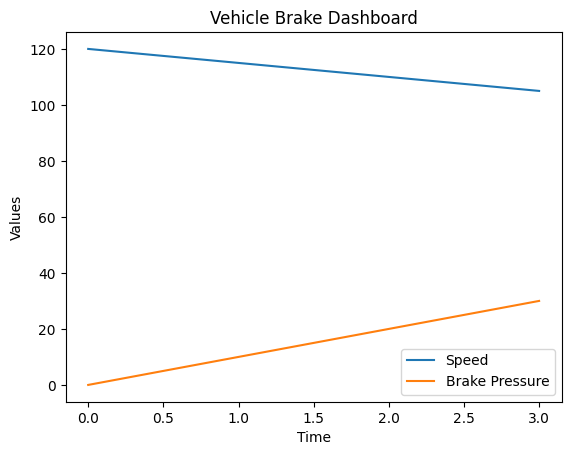

In [ ]:
import matplotlib.pyplot as plt

speed_data = [120,115,110,105]
pressure_data = [0,10,20,30]

plt.plot(speed_data,label="Speed")
plt.plot(pressure_data,label="Brake Pressure")

plt.title("Vehicle Brake Dashboard")
plt.xlabel("Time")
plt.ylabel("Values")

plt.legend()
plt.show()